In [5]:
!pip install scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. LOAD DATA
# ==============================
print("Завантаження даних... Будь ласка, зачекайте.")
df = pd.read_csv('demand_train_val_1.5years.csv')

# ==============================
# 2. TIMESTAMP PARSING
# ==============================
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ==============================
# 3. BASIC INFO
# ==============================
print("\n--- ЗАГАЛЬНА ІНФОРМАЦІЯ ---")
print(f"Загальна кількість рядків: {df.shape[0]}")

df.info()

print("\n--- TIME RANGE ---")
print("Min timestamp:", df['timestamp'].min())
print("Max timestamp:", df['timestamp'].max())

print("\n--- DUPLICATES CHECK ---")
print("Duplicate timestamps:", df['timestamp'].duplicated().sum())

# ==============================
# 4. MISSING VALUES ANALYSIS
# ==============================
print("\n--- АНАЛІЗ ПРОПУЩЕНИХ ДАНИХ ---")

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

print(missing_df.sort_values(by='Missing Count', ascending=False))

Завантаження даних... Будь ласка, зачекайте.

--- ЗАГАЛЬНА ІНФОРМАЦІЯ ---
Загальна кількість рядків: 78486
<class 'pandas.DataFrame'>
RangeIndex: 78486 entries, 0 to 78485
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             78486 non-null  datetime64[us]
 1   store_id              78486 non-null  int64         
 2   product_id            78486 non-null  int64         
 3   temperature           76601 non-null  float64       
 4   local_event_factor    78486 non-null  float64       
 5   price                 78486 non-null  float64       
 6   is_promo              78486 non-null  int64         
 7   competitor_price      66728 non-null  float64       
 8   delivery_delay_hours  78486 non-null  int64         
 9   holiday_factor        78486 non-null  float64       
 10  app_clicks            72117 non-null  float64       
 11  stock_on_hand         78486 non-null


--- CENSORING ---
Censored hours: 35381
Percentage: 45.08%


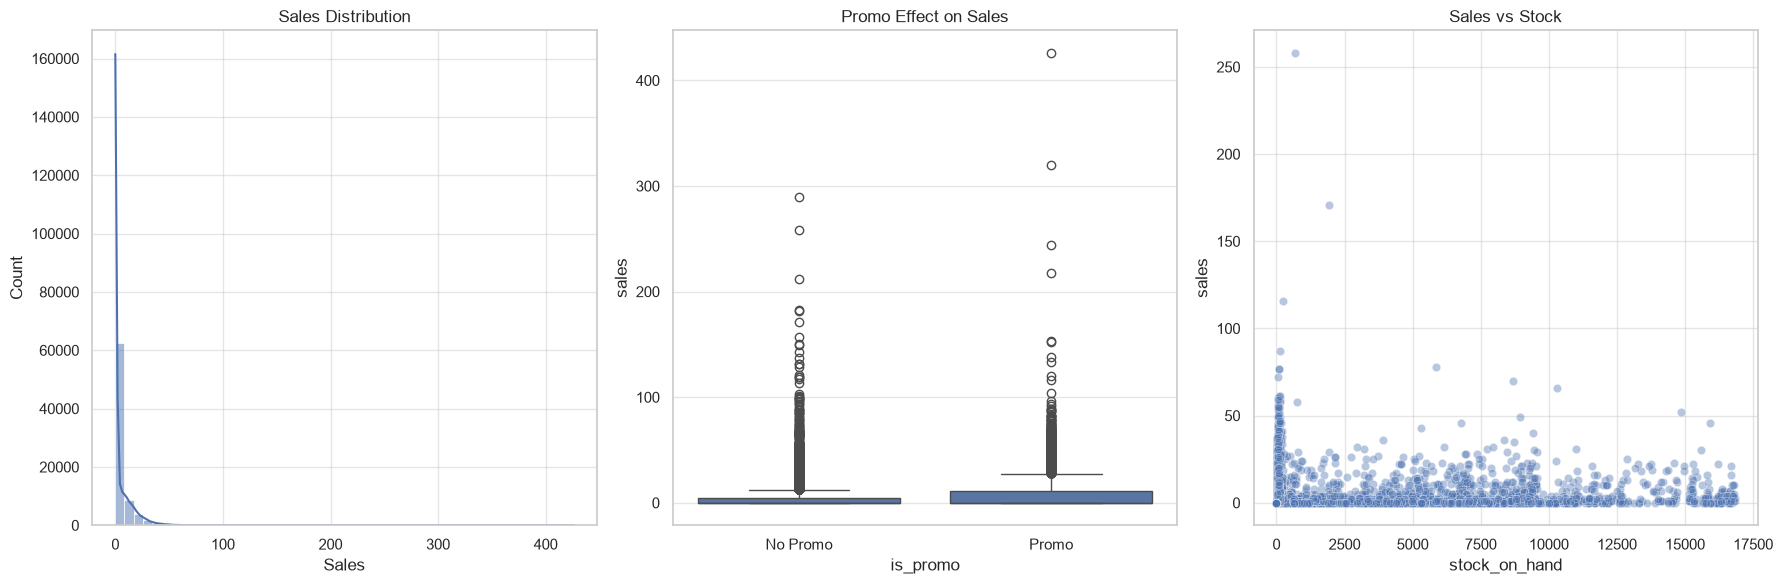

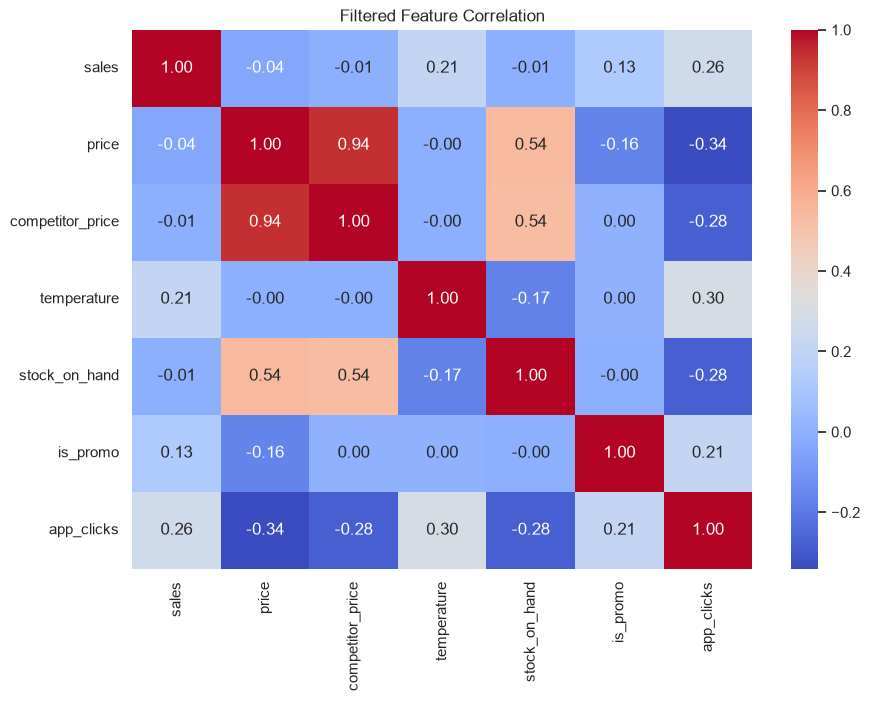

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STYLE
# ==============================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

df = df.dropna(subset=['sales', 'stock_on_hand'])

# ==============================
# FIGURE (3 plots only)
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ==============================
# 1. SALES DISTRIBUTION
# ==============================
sns.histplot(df['sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')

# ==============================
# 2. PROMO EFFECT
# ==============================
sns.boxplot(x='is_promo', y='sales', data=df, ax=axes[1])
axes[1].set_title('Promo Effect on Sales')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Promo', 'Promo'])

# ==============================
# 3. CENSORING ANALYSIS
# ==============================
df['is_censored'] = (df['stock_on_hand'] == 0).astype(int)

censored_cases = df[df['is_censored'] == 1].shape[0]
censored_percent = censored_cases / len(df) * 100

print("\n--- CENSORING ---")
print(f"Censored hours: {censored_cases}")
print(f"Percentage: {censored_percent:.2f}%")

sns.scatterplot(
    x='stock_on_hand',
    y='sales',
    data=df.sample(5000, random_state=42),
    ax=axes[2],
    alpha=0.4
)
axes[2].set_title('Sales vs Stock')

plt.tight_layout()
plt.show()

# ==============================
# CORRELATION (FILTERED)
# ==============================
corr_cols = [
    'sales', 'price', 'competitor_price',
    'temperature', 'stock_on_hand',
    'is_promo', 'app_clicks'
]

plt.figure(figsize=(10, 7))
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Filtered Feature Correlation')
plt.show()

In [8]:
import pandas as pd
import numpy as np

# Робимо копію датасету для трансформацій
df_clean = df.copy()

# ==========================================
# 1. ЗАПОВНЕННЯ ПРОПУСКІВ У ПОГОДІ ТА ЦІНАХ
# ==========================================
print("Очищення даних та заповнення пропусків...")

# Погода: інтерполяція + backfill
df_clean['temperature'] = df_clean['temperature'].interpolate(method='linear').bfill()

# Ціни конкурентів: якщо пропуск — беремо нашу ціну
df_clean['competitor_price'] = df_clean['competitor_price'].fillna(df_clean['price'])

# Кліки: одразу заповнюємо, щоб уникнути NaN у розрахунках
df_clean['app_clicks'] = df_clean['app_clicks'].fillna(0)


# ==========================================
# 2. РЕКОНСТРУКЦІЯ ЦЕНЗУРОВАНОГО ПОПИТУ
# ==========================================
print("Реконструкція прихованого попиту (Demand Censoring)...")

# Беремо тільки валідні випадки
valid_data = df_clean[
    (df_clean['stock_on_hand'] > 0) &
    (df_clean['app_clicks'] > 0)
].copy()

# Захист від ділення на нуль
if len(valid_data) > 0:
    conversion_ratio = valid_data['sales'] / valid_data['app_clicks']
    mean_conversion = conversion_ratio.replace([np.inf, -np.inf], np.nan).mean()
else:
    mean_conversion = 0

print(f"Розрахована середня конверсія кліків у продажі: {mean_conversion:.4f}")

# Ініціалізуємо реконструйований попит
df_clean['reconstructed_demand'] = df_clean['sales'].astype(float)

# Маска для цензурованого попиту (нема товару, але є попит)
censored_mask = (
    (df_clean['stock_on_hand'] == 0) &
    (df_clean['app_clicks'] > 0)
)

# Розрахунок потенційного попиту
raw_demand = df_clean.loc[censored_mask, 'app_clicks'] * mean_conversion

# Записуємо результат
df_clean.loc[censored_mask, 'reconstructed_demand'] = np.round(raw_demand)


# ==========================================
# 3. ПЕРЕВІРКА РЕЗУЛЬТАТІВ
# ==========================================
print("\n--- ПЕРЕВІРКА ПІСЛЯ ОЧИЩЕННЯ ---")

print("Залишилося пропусків у таблиці:\n")
print(df_clean.isnull().sum())

print(f"\nЗагальна сума реальних продажів (sales): {df_clean['sales'].sum():,.0f}")
print(f"Загальна сума відновленого попиту (reconstructed_demand): {df_clean['reconstructed_demand'].sum():,.0f}")

Очищення даних та заповнення пропусків...
Реконструкція прихованого попиту (Demand Censoring)...
Розрахована середня конверсія кліків у продажі: 0.2609

--- ПЕРЕВІРКА ПІСЛЯ ОЧИЩЕННЯ ---
Залишилося пропусків у таблиці:

timestamp               0
store_id                0
product_id              0
temperature             0
local_event_factor      0
price                   0
is_promo                0
competitor_price        0
delivery_delay_hours    0
holiday_factor          0
app_clicks              0
stock_on_hand           0
sales                   0
is_censored             0
reconstructed_demand    0
dtype: int64

Загальна сума реальних продажів (sales): 375,030
Загальна сума відновленого попиту (reconstructed_demand): 1,118,428


In [9]:
print("Генерація часових та цінових ознак (Feature Engineering)...")

# ==========================================
# 0. ЗАХИСТИ (важливо для стабільності)
# ==========================================

# Переконуємося, що timestamp у datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')

# Видаляємо або заповнюємо некоректні timestamp (NaT)
if df_clean['timestamp'].isna().sum() > 0:
    print(f"⚠️ Знайдено NaT у timestamp: {df_clean['timestamp'].isna().sum()} рядків")
    df_clean = df_clean.dropna(subset=['timestamp']).copy()


# ==========================================
# 1. ЧАСОВІ ОЗНАКИ
# ==========================================

df_clean['hour'] = df_clean['timestamp'].dt.hour.astype('int16')
df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek.astype('int8')
df_clean['month'] = df_clean['timestamp'].dt.month.astype('int8')

df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype('int8')


# ==========================================
# 2. ЦІНОВА ОЗНАКА
# ==========================================

# Захист від NaN (якщо раптом не заповнено раніше)
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())
df_clean['competitor_price'] = df_clean['competitor_price'].fillna(df_clean['price'])

df_clean['price_diff'] = df_clean['price'] - df_clean['competitor_price']


# ==========================================
# 3. ПЕРЕВІРКА
# ==========================================

print("Нові ознаки успішно створено!")

print(
    df_clean[
        ['timestamp', 'hour', 'day_of_week', 'month', 'is_weekend', 'price_diff']
    ].head()
)

Генерація часових та цінових ознак (Feature Engineering)...
Нові ознаки успішно створено!
            timestamp  hour  day_of_week  month  is_weekend  price_diff
0 2025-01-01 00:00:00     0            2      1           0    5.610090
1 2025-01-01 01:00:00     1            2      1           0   -3.727214
2 2025-01-01 02:00:00     2            2      1           0    0.109468
3 2025-01-01 03:00:00     3            2      1           0    1.289763
4 2025-01-01 04:00:00     4            2      1           0    0.228298


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ==========================================
# BASELINE MODELS COMPARISON
# ==========================================

naive_pred = test_df['sales_lag_1']
seasonal_pred = test_df['sales_lag_24']

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

seasonal_mae = mean_absolute_error(y_test, seasonal_pred)
seasonal_rmse = np.sqrt(mean_squared_error(y_test, seasonal_pred))

comparison_df = pd.DataFrame({
    'Model': [
        'Naive Forecast (previous hour)',
        'Seasonal Naive Forecast (same hour previous day)',
        'LightGBM improved model'
    ],
    'MAE': [
        naive_mae,
        seasonal_mae,
        mae
    ],
    'RMSE': [
        naive_rmse,
        seasonal_rmse,
        rmse
    ]
})

comparison_df = comparison_df.round(2)

print("\n--- MODEL COMPARISON ---")
print(comparison_df.to_string(index=False))

best_baseline_mae = min(naive_mae, seasonal_mae)
best_baseline_rmse = min(naive_rmse, seasonal_rmse)

mae_improvement = (best_baseline_mae - mae) / best_baseline_mae * 100
rmse_improvement = (best_baseline_rmse - rmse) / best_baseline_rmse * 100

print("\n--- IMPROVEMENT VS BEST BASELINE ---")
print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")


--- MODEL COMPARISON ---
                                           Model  MAE  RMSE
                  Naive Forecast (previous hour) 8.72 17.07
Seasonal Naive Forecast (same hour previous day) 7.66 15.07
                         LightGBM improved model 2.13  6.23

--- IMPROVEMENT VS BEST BASELINE ---
MAE improvement: 72.15%
RMSE improvement: 58.63%


In [10]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Підготовка даних до моделювання...")

# Сортуємо дані за часом, щоб випадково не порушити хронологію
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)

# Визначаємо цільову змінну (прогнозуємо відновлений попит)
# ==============================
# FIX 2: CLEAN TARGET (NO SYNTHETIC BIAS)
# ==============================

target = 'sales'

# додатково: мітка цензури (дуже важливо для бізнесу)
df_clean['is_censored'] = (df_clean['stock_on_hand'] == 0).astype(int)

# Вибираємо тільки ті ознаки, які бізнес знає наперед на 3 місяці (час, погода, промо, свята, затримки доставки)
features = [
    'store_id', 'product_id', 'temperature', 'local_event_factor',
    'price', 'is_promo', 'competitor_price', 'delivery_delay_hours',
    'holiday_factor', 'hour', 'day_of_week', 'month', 'is_weekend', 'price_diff'
]
# ==============================
# FIX 3: TIME SERIES FEATURES (LAGS + ROLLING)
# ==============================

df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)

# LAGS (історія попиту)
df_clean['sales_lag_1'] = df_clean['sales'].shift(1)
df_clean['sales_lag_24'] = df_clean['sales'].shift(24)
df_clean['sales_lag_168'] = df_clean['sales'].shift(168)

# ROLLING STATISTICS
df_clean['sales_roll_mean_24'] = df_clean['sales'].rolling(window=24).mean()
df_clean['sales_roll_mean_168'] = df_clean['sales'].rolling(window=168).mean()

df_clean['sales_roll_std_24'] = df_clean['sales'].rolling(window=24).std()

# PRICE FEATURES (еластичність)
df_clean['price_ratio'] = df_clean['price'] / df_clean['competitor_price']
df_clean['price_diff_abs'] = df_clean['price'] - df_clean['competitor_price']
df_clean['price_diff_abs'] = df_clean['price_diff_abs'].abs()

# CLEAN
df_clean = df_clean.dropna().reset_index(drop=True)

print("Feature engineering completed:", df_clean.shape)
# Робимо розподіл за часом: останні 3 місяці (приблизно 90 днів) віддаємо на тест
# Погодинних записів багато, тому відріжемо останні 20% даних для тестування
# ==============================
# FIX 1: SORT + TIME SPLIT (NO LEAKAGE)
# ==============================

df_clean = df_clean.sort_values(['timestamp', 'store_id', 'product_id']).reset_index(drop=True)

# категоріальні ознаки (ВАЖЛИВО)
df_clean['store_id'] = df_clean['store_id'].astype('category')
df_clean['product_id'] = df_clean['product_id'].astype('category')

# time-based split (80/20 по часу)
cutoff = df_clean['timestamp'].quantile(0.8)

train_df = df_clean[df_clean['timestamp'] <= cutoff].copy()
test_df = df_clean[df_clean['timestamp'] > cutoff].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Розмір вибірки для навчання (Train): {X_train.shape}")
print(f"Розмір вибірки для тесту (Test): {X_test.shape}")

# Створюємо та навчаємо модель градієнтного бустингу
print("\nНавчання моделі LightGBM... Це може зайняти до 1 хвилини.")
# ==============================
# FIX 4: STRONGER LIGHTGBM MODEL
# ==============================

model_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(X_train, y_train)

preds = model_lgb.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n--- IMPROVED MODEL RESULTS ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
model_lgb.fit(X_train, y_train)

# Робимо прогноз на тестових даних
preds = model_lgb.predict(X_test)

# Оцінюємо якість прогнозу (метрики MAE та RMSE)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n--- РЕЗУЛЬТАТИ ОЦІНКИ МОДЕЛІ ---")
print(f"Середня абсолютна помилка (MAE): {mae:.2f} одиниць товару")
print(f"Корінь з середньоквадратичної помилки (RMSE): {rmse:.2f}")


Підготовка даних до моделювання...
Feature engineering completed: (78318, 28)
Train shape: (62658, 14)
Test shape: (15660, 14)
Розмір вибірки для навчання (Train): (62658, 14)
Розмір вибірки для тесту (Test): (15660, 14)

Навчання моделі LightGBM... Це може зайняти до 1 хвилини.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1347
[LightGBM] [Info] Number of data points in the train set: 62658, number of used features: 14
[LightGBM] [Info] Start training from score 4.303569

--- IMPROVED MODEL RESULTS ---
MAE: 3.55
RMSE: 9.20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1347
[

In [11]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("Підготовка даних до моделювання...")

# ==========================================
# 1. СОРТУВАННЯ
# ==========================================
df_clean = df_clean.sort_values(['timestamp', 'store_id', 'product_id']).reset_index(drop=True)

# ==========================================
# 2. TARGET + CENSORED FLAG
# ==========================================
target = 'sales'
df_clean['is_censored'] = (df_clean['stock_on_hand'] == 0).astype('int8')

# ==========================================
# 3. LAG FEATURES
# ==========================================
df_clean['sales_lag_1'] = df_clean['sales'].shift(1)
df_clean['sales_lag_24'] = df_clean['sales'].shift(24)
df_clean['sales_lag_168'] = df_clean['sales'].shift(168)

# ==========================================
# 4. ROLLING FEATURES
# ==========================================
df_clean['sales_roll_mean_24'] = df_clean['sales'].rolling(24).mean()
df_clean['sales_roll_mean_168'] = df_clean['sales'].rolling(168).mean()
df_clean['sales_roll_std_24'] = df_clean['sales'].rolling(24).std()

# ==========================================
# 5. PRICE FEATURES (SAFE)
# ==========================================
df_clean['competitor_price'] = df_clean['competitor_price'].replace(0, np.nan)
df_clean['competitor_price'] = df_clean['competitor_price'].fillna(df_clean['price'])

df_clean['price_ratio'] = df_clean['price'] / df_clean['competitor_price']
df_clean['price_diff_abs'] = (df_clean['price'] - df_clean['competitor_price']).abs()

# ==========================================
# 6. CLEAN DATA (IMPORTANT BEFORE SPLIT)
# ==========================================
df_clean = df_clean.dropna().reset_index(drop=True)

print("Feature engineering completed:", df_clean.shape)

# ==========================================
# 7. TIME SPLIT (NO LEAKAGE)
# ==========================================
cutoff = df_clean['timestamp'].quantile(0.8)

train_df = df_clean[df_clean['timestamp'] <= cutoff].copy()
test_df = df_clean[df_clean['timestamp'] > cutoff].copy()

# categorical encoding
train_df['store_id'] = train_df['store_id'].astype('category')
train_df['product_id'] = train_df['product_id'].astype('category')

test_df['store_id'] = test_df['store_id'].astype('category')
test_df['product_id'] = test_df['product_id'].astype('category')

# ==========================================
# 8. FEATURES (ВАЖЛИВО: ДОДАЛИ ВСЕ)
# ==========================================
features = [
    'store_id', 'product_id',
    'temperature', 'local_event_factor',
    'price', 'is_promo', 'competitor_price',
    'delivery_delay_hours', 'holiday_factor',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'price_diff',

    # NEW FEATURES
    'is_censored',
    'sales_lag_1', 'sales_lag_24', 'sales_lag_168',
    'sales_roll_mean_24', 'sales_roll_mean_168',
    'sales_roll_std_24',
    'price_ratio', 'price_diff_abs'
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 9. MODEL
# ==========================================
print("\nНавчання моделі LightGBM...")

model_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(X_train, y_train)

# ==========================================
# 10. PREDICTION + EVAL
# ==========================================
preds = model_lgb.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n--- MODEL RESULTS ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Підготовка даних до моделювання...
Feature engineering completed: (78150, 28)
Train shape: (62520, 23)
Test shape: (15630, 23)

Навчання моделі LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2876
[LightGBM] [Info] Number of data points in the train set: 62520, number of used features: 23
[LightGBM] [Info] Start training from score 4.309149

--- MODEL RESULTS ---
MAE: 2.13
RMSE: 6.23


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Baseline 1
naive_pred = test_df['sales_lag_1']

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

# Baseline 2
seasonal_pred = test_df['sales_lag_24']

seasonal_mae = mean_absolute_error(y_test, seasonal_pred)
seasonal_rmse = np.sqrt(mean_squared_error(y_test, seasonal_pred))

comparison_df = pd.DataFrame({
    'Model': [
        'Naive Forecast',
        'Seasonal Naive Forecast',
        'LightGBM'
    ],
    'MAE': [
        naive_mae,
        seasonal_mae,
        mae
    ],
    'RMSE': [
        naive_rmse,
        seasonal_rmse,
        rmse
    ]
})

comparison_df = comparison_df.round(2)

print(comparison_df.to_string(index=False))

                  Model  MAE  RMSE
         Naive Forecast 8.72 17.07
Seasonal Naive Forecast 7.66 15.07
               LightGBM 2.13  6.23


In [13]:
import joblib
from datetime import datetime

# ==========================================
# 1. SAFETY CHECK
# ==========================================
try:
    model_lgb
except NameError:
    raise Exception("Модель model_lgb не знайдена. Спочатку запусти training cell.")

# ==========================================
# 2. MODEL VERSIONING
# ==========================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"demand_lightgbm_model_{timestamp}.pkl"

# ==========================================
# 3. SAVE MODEL (RECOMMENDED: joblib)
# ==========================================
joblib.dump(model_lgb, model_filename)

print(f"✅ Модель успішно збережено: {model_filename}")
print("📦 Ви можете знайти файл у папці проєкту та передати замовнику")

# ==========================================
# 4. HOW TO LOAD (FOR CLIENT)
# ==========================================
print("\n--- ЯК ЗАВАНТАЖИТИ МОДЕЛЬ ---")
print("""
import joblib

model = joblib.load('demand_lightgbm_model_YYYYMMDD_HHMM.pkl')
preds = model.predict(X)
""")

✅ Модель успішно збережено: demand_lightgbm_model_20260618_1702.pkl
📦 Ви можете знайти файл у папці проєкту та передати замовнику

--- ЯК ЗАВАНТАЖИТИ МОДЕЛЬ ---

import joblib

model = joblib.load('demand_lightgbm_model_YYYYMMDD_HHMM.pkl')
preds = model.predict(X)

